# **Team Name:** `B Team`
# **Authors:** `Madelyne Dusbabek, Gregory Lowman, Jay Hall`
# **Cell Number:** `R22`
# **J-V Apparatus Number:** `JV 1`
# **EQE Apparatus Number:** `EQE 1`

### This week you will do the following data analysis:

1.   Calculate PCE values and uncertainties for all pixels. Write the PCE values, PCE uncertainties, and $J_{sc}$ values to a CSV file. Paste the output of your CSV file in the notebook. **You have done this analysis in previous Colab notebooks. Please copy, edit, and reuse your code from previous weeks.**

2. You will plot your PCE values with error bars to show how they changed from the baseline to this week's data. Your figure should now have **seven** time points: baseline data, Data Collection 1, Data Collection 2, break week (TA data), Data Collection 3, Data Collection 4, and Data Collection 5 (this week), accounting for any pixels that may have failed during stressing. **You have done this analysis in previous Colab notebooks. Please copy, edit, and reuse your code from previous weeks.**

3.   Plot all spectra from the stressing stations and overplot the mean spectrum. Then, create histograms at different wavelengths to explore how the intensity distribution varies across stressing stations, and assess whether a Gaussian is a good description of the data.

4. Create a CSV file with your EQE values for this week. Then, use all of your EQE data CSV files (Baseline through Data Collection 5) to generate subplots for each pixel showing how the EQE spectrum changes over time.
Each subplot should include all **seven** time points (baseline, Data Collection 1, Data Collection 2, break week, Data Collection 3, Data Collection 4, and Data Collection 5), accounting for any pixels that may have failed during stressing. **You have done this analysis in previous Colab notebooks. Please copy, edit, and reuse your code from previous weeks.**

## **J-V Analysis**

1. Calculate the $J_{sc}$ and PCE values for each pixel. Remember to follow the uncertainty workflow from Data Collection 2: create power vs. voltage plots, estimate $dV_{pmax}$ and $dJ_{pmax}$, and propagate uncertainties to produce your final CSV with `PCE_uncertainty (%)`. **Remember to update the time values for this week's data.**

In [1]:
# Week 8
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

AREA = 0.14  # cm^2

folder = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/JV_Data"

if not os.path.exists(folder):
    raise FileNotFoundError(f"Folder not found:\n{folder}")

files = sorted(
    f for f in os.listdir(folder)
    if f.endswith(".csv") and "_IV_cell" in f and "_pixel" in f
)

if not files:
    raise SystemExit("No JV files found in folder.")

jv_data = {}

for f in files:
    full_path = os.path.join(folder, f)
    df = pd.read_csv(full_path)

    df.columns = df.columns.str.strip()

    # Verify required columns exist
    required_cols = ["Voltage (V)", "Forward_mean (mA)"]
    if not all(col in df.columns for col in required_cols):
        print(f"[skip] Unexpected format: {f}")
        continue

    name = f.replace(".csv", "")

    jv_data[name] = pd.DataFrame({
        "Voltage (V)": pd.to_numeric(df["Voltage (V)"], errors="coerce"),
        "Current Density (mA/cm^2)":
            pd.to_numeric(df["Forward_mean (mA)"], errors="coerce") / AREA
    })

print(f"[ok] Loaded {len(jv_data)} JV files")

###############################################################################

date_str = "2026_03_24"
cell_id  = "R22"
area_cm2 = 0.14
P_in = 99.8
pixels = range(1, 9)

folder = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/JV_Data"

COL_V          = "Voltage (V)"
COL_Forward_mA = "Forward_mean (mA)"
COL_Fwd_std    = "Forward_std (mA)"
COL_Fwd_n      = "Forward_n"

raw_data = {}
jv_data  = {}

for n in pixels:
    fname = f"{date_str}_IV_cell{cell_id}_pixel{n}.csv"
    try:
        df_raw = pd.read_csv(os.path.join(folder, fname))
        raw_data[n] = df_raw

        df_jv = pd.DataFrame({
            "Voltage (V)": df_raw[COL_V].astype(float),
            "Current Density (mA/cm^2)": df_raw[COL_Forward_mA].astype(float) / area_cm2
        }).sort_values("Voltage (V)").reset_index(drop=True)

        df_jv["Power Density (mW/cm^2)"] = (
            df_jv["Voltage (V)"] * df_jv["Current Density (mA/cm^2)"]
        )

        jv_data[n] = df_jv
        print(f"[ok] Loaded pixel {n}")

    except FileNotFoundError:
        print(f"[skip] Pixel {n}: file not found ({fname})")
    except Exception as e:
        print(f"[skip] Pixel {n}: error reading {fname}: {e}")

rows = []
valid_pixels = sorted(jv_data.keys())

for n in valid_pixels:
    jv  = jv_data[n]
    raw = raw_data[n].sort_values(COL_V).reset_index(drop=True)

    V = jv["Voltage (V)"].to_numpy()
    J = jv["Current Density (mA/cm^2)"].to_numpy()

    Voc = float(np.interp(0.0, J, V))
    Jsc = float(np.interp(0.0, V, J))
    P   = V * J
    idx_pmax = int(np.argmin(P))
    Vmp = float(V[idx_pmax])
    Jmp = float(J[idx_pmax])

    denom = abs(Jsc) * Voc
    FF  = (Vmp * abs(Jmp)) / denom if denom != 0 else np.nan
    PCE = ((Voc * abs(Jsc) * FF) / P_in) * 100 if P_in != 0 else np.nan

    std_mA_mpp = float(raw[COL_Fwd_std].iloc[idx_pmax])
    n_mpp      = float(raw[COL_Fwd_n].iloc[idx_pmax])

    if n_mpp > 1:
        SE_I_mpp = std_mA_mpp / np.sqrt(n_mpp)
        SE_J_mpp = SE_I_mpp / area_cm2
    else:
        SE_J_mpp = np.nan
        print(f"  [warn] Pixel {n}: n=1 at MPP, SE undefined")

    idx_v0 = int(np.argmin(np.abs(raw[COL_V].to_numpy())))
    std_mA_v0 = float(raw[COL_Fwd_std].iloc[idx_v0])
    n_v0      = float(raw[COL_Fwd_n].iloc[idx_v0])

    if n_v0 > 1:
        SE_Jsc = (std_mA_v0 / np.sqrt(n_v0)) / area_cm2
    else:
        SE_Jsc = np.nan

    if len(V) > 1:
        voltage_step = float(np.median(np.abs(np.diff(V))))
        dV = voltage_step / 2.0
    else:
        dV = np.nan

    rows.append({
        "Pixel Number":        n,
        "Jsc (mA/cm^2)":      Jsc,
        "SE_Jsc (mA/cm^2)":   SE_Jsc,
        "J_pmax (mA/cm^2)":   Jmp,
        "V_pmax (V)":         Vmp,
        "PCE":                PCE,
        "SE_Jpmax (mA/cm^2)": SE_J_mpp,
        "dV (V)":             dV,
        "n_at_MPP":           n_mpp,
    })

out_name = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/2026_03_24_jsc_pce_cellR22.csv"
df_out = pd.DataFrame(rows)
df_out.sort_values("Pixel Number").to_csv(out_name, index=False)

if df_out.empty:
    print("[warn] No valid pixels found — did you run the loader above?")
else:
    df_out.sort_values("Pixel Number").to_csv(out_name, index=False)
    print(f"\n[ok] Wrote {out_name}")
    display(df_out)

Mounted at /content/drive
[ok] Loaded 8 JV files
[ok] Loaded pixel 1
[ok] Loaded pixel 2
[ok] Loaded pixel 3
[ok] Loaded pixel 4
[ok] Loaded pixel 5
[ok] Loaded pixel 6
[ok] Loaded pixel 7
[ok] Loaded pixel 8

[ok] Wrote /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/2026_03_24_jsc_pce_cellR22.csv


,Pixel Number,Jsc (mA/cm^2),SE_Jsc (mA/cm^2),J_pmax (mA/cm^2),V_pmax (V),PCE,SE_Jpmax (mA/cm^2),dV (V),n_at_MPP
0,1,-6.671500,0.004490,-5.368714,0.86,4.626347,0.004183,0.01,10.0
1,2,-6.708071,0.003860,-5.121071,0.90,4.618201,0.003817,0.01,10.0
2,3,-7.266929,0.006383,-5.361214,0.92,4.942202,0.006925,0.01,10.0
3,4,-6.149714,0.002561,-4.369571,0.84,3.677796,0.002137,0.01,10.0
4,5,-6.598500,0.003763,-5.139571,0.88,4.531887,0.002480,0.01,10.0
5,6,-12.797357,0.005751,-10.086643,0.94,9.500445,0.004859,0.01,10.0
6,7,-7.750714,0.004271,-5.866500,0.92,5.407996,0.006205,0.01,10.0
7,8,-10.316357,0.006105,-7.845786,0.92,7.232588,0.003483,0.01,10.0


Use this cell to paste your PCE+uncertainties for this week's data.

Creating PCE JSC Cell

Creating the uncertainty csv

In [2]:
# --- PCE Uncertainty Propagation using Standard Error ---
df = pd.read_csv("/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/2026_03_24_jsc_pce_cellR22.csv")

# Time variable — update depending on the week
t = 1344  # hours since initial measurement (update each week)
df["Time (hr)"] = t

# Uncertainty in light power (from solar simulator calibration)
dP_in = 0.9  # mW/cm^2

# --- Propagate uncertainty for PCE ---
J_abs   = np.abs(df["J_pmax (mA/cm^2)"].to_numpy())
V_vals  = np.abs(df["V_pmax (V)"].to_numpy())
PCE_vals = df["PCE"].to_numpy()
dJ      = df["SE_Jpmax (mA/cm^2)"].to_numpy()
dV      = df["dV (V)"].to_numpy()

# Relative uncertainties
rel_J   = dJ / J_abs
rel_V   = dV / V_vals
rel_Pin = dP_in / P_in

# PCE uncertainty (in percentage points, same units as PCE)
df["PCE_uncertainty (%)"] = PCE_vals * np.sqrt(rel_J**2 + rel_V**2 + rel_Pin**2)

# Jsc uncertainty for reporting
df["Jsc_uncertainty (mA/cm^2)"] = df["SE_Jsc (mA/cm^2)"]

# Write final output
folder_name = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8"
out_name = f"{folder_name}/{date_str}_jsc_pce_uncertainties_cell{cell_id}.csv"
cols_to_write = [
    "Pixel Number", "Time (hr)",
    "Jsc (mA/cm^2)", "Jsc_uncertainty (mA/cm^2)",
    "PCE", "PCE_uncertainty (%)"
]
df[cols_to_write].to_csv(out_name, index=False)
print(f"[ok] Wrote {out_name}")
display(df[cols_to_write])

# Print a summary for quick review
print("\n--- Summary ---")
for _, row in df.iterrows():
    pix = int(row["Pixel Number"])
    pce = row["PCE"]
    dpce = row["PCE_uncertainty (%)"]
    jsc = row["Jsc (mA/cm^2)"]
    djsc = row["Jsc_uncertainty (mA/cm^2)"]
    print(f"  Pixel {pix}: PCE = {pce:.2f} +/- {dpce:.2f} %,  "
          f"Jsc = {jsc:.3f} +/- {djsc:.3f} mA/cm^2")

# --- Relative uncertainty breakdown ---
print("\n--- Relative Uncertainty Breakdown (as %) ---")
print(f"  {'Pixel':>5s}  {'δJ/J':>8s}  {'δV/V':>8s}  {'δP/P':>8s}  {'Total':>8s}")
for _, row in df.iterrows():
    pix = int(row["Pixel Number"])
    rJ = row["SE_Jpmax (mA/cm^2)"] / abs(row["J_pmax (mA/cm^2)"]) * 100
    rV = row["dV (V)"] / abs(row["V_pmax (V)"]) * 100
    rP = dP_in / P_in * 100
    total = np.sqrt((rJ/100)**2 + (rV/100)**2 + (rP/100)**2) * 100
    print(f"  {pix:5d}  {rJ:7.3f}%  {rV:7.3f}%  {rP:7.3f}%  {total:7.3f}%")

print(f"\n  Note: δJ/J is the SE-based measurement uncertainty (statistical).")
print(f"        δV/V is the voltage step resolution (instrumental).")
print(f"        δP/P is the solar simulator calibration (systematic).")

[ok] Wrote /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/2026_03_24_jsc_pce_uncertainties_cellR22.csv


,Pixel Number,Time (hr),Jsc (mA/cm^2),Jsc_uncertainty (mA/cm^2),PCE,PCE_uncertainty (%)
0,1,1344,-6.671500,0.004490,4.626347,0.068172
1,2,1344,-6.708071,0.003860,4.618201,0.066177
2,3,1344,-7.266929,0.006383,4.942202,0.070092
3,4,1344,-6.149714,0.002561,3.677796,0.054957
4,5,1344,-6.598500,0.003763,4.531887,0.065781
5,6,1344,-12.797357,0.005751,9.500445,0.132575
6,7,1344,-7.750714,0.004271,5.407996,0.076594
7,8,1344,-10.316357,0.006105,7.232588,0.102200



--- Summary ---
  Pixel 1: PCE = 4.63 +/- 0.07 %,  Jsc = -6.671 +/- 0.004 mA/cm^2
  Pixel 2: PCE = 4.62 +/- 0.07 %,  Jsc = -6.708 +/- 0.004 mA/cm^2
  Pixel 3: PCE = 4.94 +/- 0.07 %,  Jsc = -7.267 +/- 0.006 mA/cm^2
  Pixel 4: PCE = 3.68 +/- 0.05 %,  Jsc = -6.150 +/- 0.003 mA/cm^2
  Pixel 5: PCE = 4.53 +/- 0.07 %,  Jsc = -6.598 +/- 0.004 mA/cm^2
  Pixel 6: PCE = 9.50 +/- 0.13 %,  Jsc = -12.797 +/- 0.006 mA/cm^2
  Pixel 7: PCE = 5.41 +/- 0.08 %,  Jsc = -7.751 +/- 0.004 mA/cm^2
  Pixel 8: PCE = 7.23 +/- 0.10 %,  Jsc = -10.316 +/- 0.006 mA/cm^2

--- Relative Uncertainty Breakdown (as %) ---
  Pixel      δJ/J      δV/V      δP/P     Total
      1    0.078%    1.163%    0.902%    1.474%
      2    0.075%    1.111%    0.902%    1.433%
      3    0.129%    1.087%    0.902%    1.418%
      4    0.049%    1.190%    0.902%    1.494%
      5    0.048%    1.136%    0.902%    1.452%
      6    0.048%    1.064%    0.902%    1.395%
      7    0.106%    1.087%    0.902%    1.416%
      8    0.044%    1

2. Plot your PCE values with error bars for each pixel. This figure should now have **seven** time points: baseline data, Data Collection 1, Data Collection 2, break week (TA data), Data Collection 3, Data Collection 4, and Data Collection 5 (this week). **Remember to update the time values for this week's data.**

Pixel 1 — Weighted Linear Fit Results
  Slope (per day): -0.048566 ± 0.013559
  Intercept  (%):  7.378 ± 0.497
  Chi-squared:      261.027
  Reduced χ²:       52.205



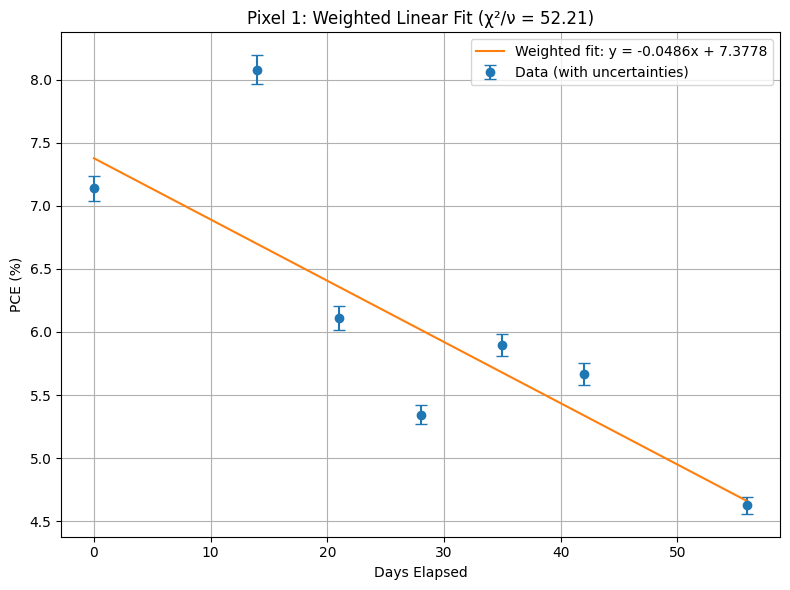

Pixel 2 — Weighted Linear Fit Results
  Slope (per day): -0.010378 ± 0.024868
  Intercept  (%):  6.266 ± 0.875
  Chi-squared:      1246.704
  Reduced χ²:       249.341



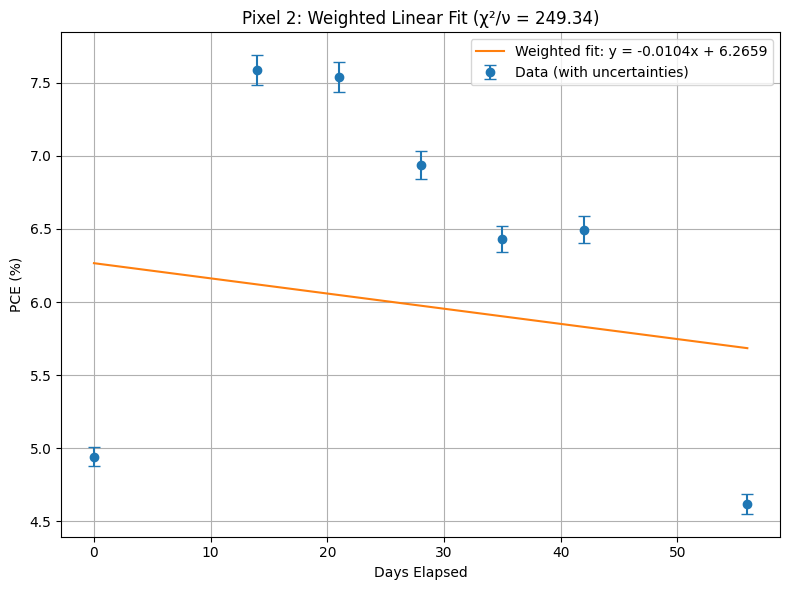

Pixel 3 — Weighted Linear Fit Results
  Slope (per day): -0.005590 ± 0.031253
  Intercept  (%):  6.535 ± 1.101
  Chi-squared:      1797.998
  Reduced χ²:       359.600



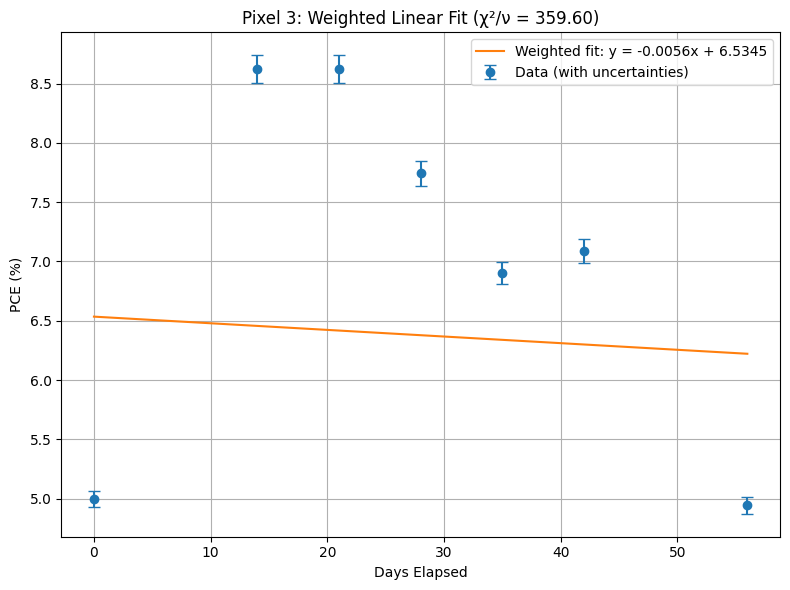

Pixel 4 — Weighted Linear Fit Results
  Slope (per day): -0.116964 ± 0.045734
  Intercept  (%):  10.989 ± 2.001
  Chi-squared:      2808.946
  Reduced χ²:       561.789



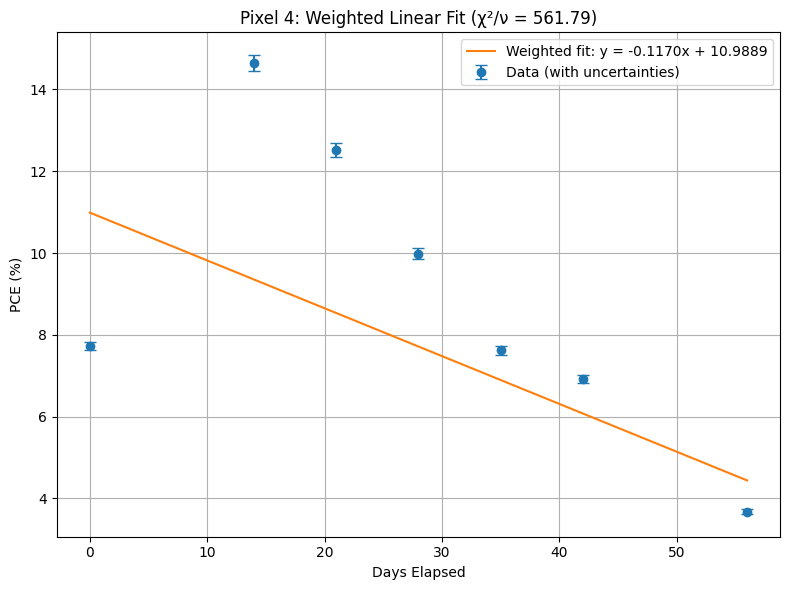

Pixel 5 — Weighted Linear Fit Results
  Slope (per day): -0.014312 ± 0.019375
  Intercept  (%):  6.179 ± 0.680
  Chi-squared:      752.136
  Reduced χ²:       150.427



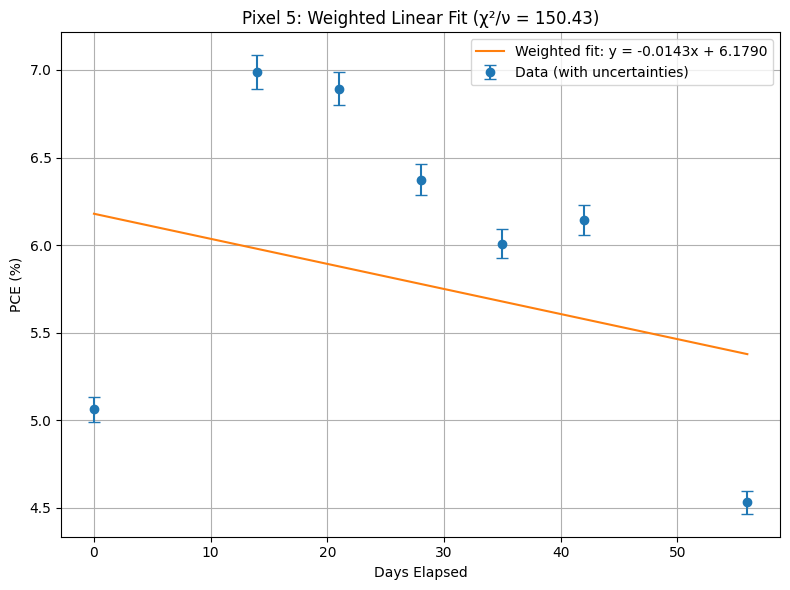

Pixel 6 — Weighted Linear Fit Results
  Slope (per day): -0.181538 ± 0.008460
  Intercept  (%):  19.600 ± 0.330
  Chi-squared:      20.966
  Reduced χ²:       4.193



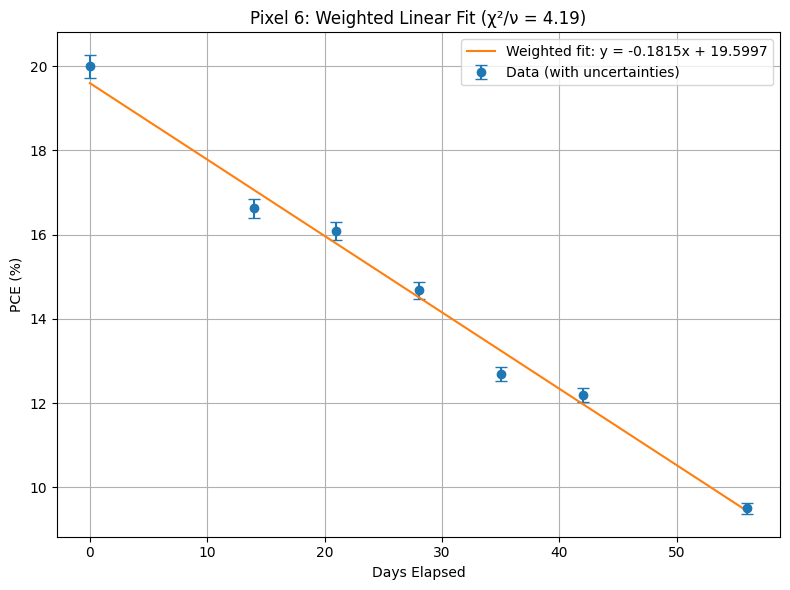

Pixel 7 — Weighted Linear Fit Results
  Slope (per day): 0.017101 ± 0.027144
  Intercept  (%):  5.755 ± 0.894
  Chi-squared:      1379.120
  Reduced χ²:       275.824



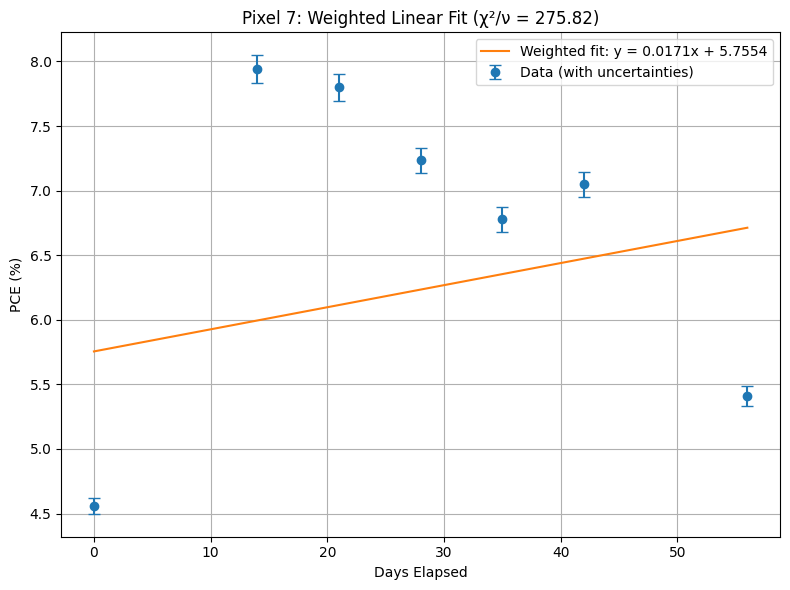

Pixel 8 — Weighted Linear Fit Results
  Slope (per day): 0.009598 ± 0.049396
  Intercept  (%):  8.674 ± 1.701
  Chi-squared:      2355.051
  Reduced χ²:       471.010



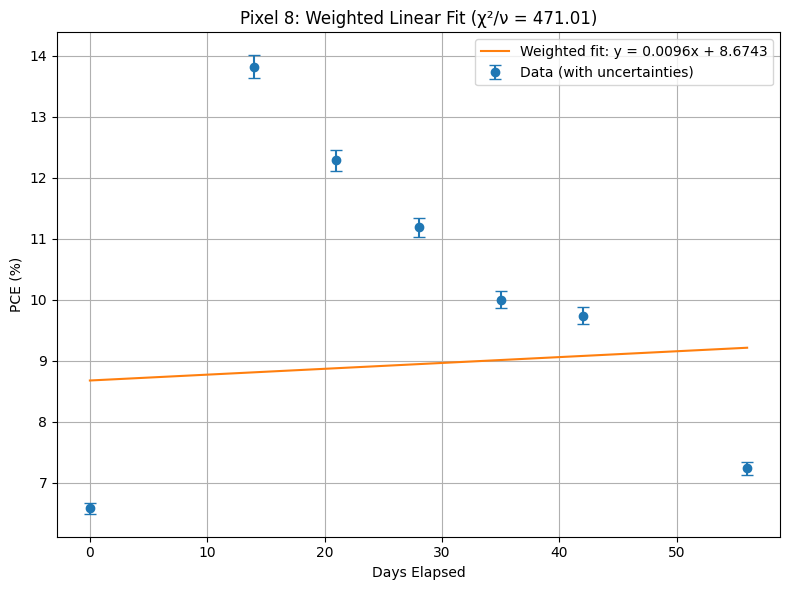

In [3]:
# Weighted Linear Regression for All 8 Pixels

files = [
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week1/2026_01_27_jsc_pce_uncertainties_cellR22.csv",
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week3/2026_02_10_jsc_pce_uncertainties_cellR22.csv",
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week4/2026_02_17_jsc_pce_uncertainties_cellR22.csv",
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week5/2026_02_24_jsc_pce_uncertainties_cellR22.csv",
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week6/2026_03_03_jsc_pce_uncertainties_cellR22.csv",
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/2026_03_10_jsc_pce_uncertainties_cellR22.csv",
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/2026_03_24_jsc_pce_uncertainties_cellR22.csv",
]
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

def weighted_linear_fit(x, y, yerr):
    yerr = np.asarray(yerr, float)
    mask = (yerr > 0) & np.isfinite(x) & np.isfinite(y)
    x, y, yerr = x[mask], y[mask], yerr[mask]

    X = np.vstack([x, np.ones_like(x)]).T
    w = 1.0 / (yerr**2)
    XTW = X.T * w
    XTWX = XTW @ X
    XTWy = XTW @ y

    beta = np.linalg.solve(XTWX, XTWy)
    cov  = np.linalg.inv(XTWX)

    y_fit = X @ beta
    resid = y - y_fit
    chi2 = np.sum((resid / yerr)**2)
    dof = max(len(y) - 2, 1)
    chi2_red = chi2 / dof

    cov_scaled = cov * chi2_red
    se = np.sqrt(np.diag(cov_scaled))

    m, b = float(beta[0]), float(beta[1])
    se_m, se_b = float(se[0]), float(se[1])
    return m, b, se_m, se_b, chi2, chi2_red, y_fit, resid

# Loop over all 8 pixels
for pixel_choice in range(1, 9):
    dfp = df[df["Pixel Number"] == pixel_choice].copy()
    if dfp.empty:
        print(f"Pixel {pixel_choice}: No data found, skipping.\n")
        continue

    x = (dfp["Time (hr)"].astype(float) / 24.0).to_numpy()
    y = dfp["PCE"].astype(float).to_numpy()
    yerr = dfp["PCE_uncertainty (%)"].astype(float).to_numpy()

    order = np.argsort(x)
    x, y, yerr = x[order], y[order], yerr[order]

    m, b, se_m, se_b, chi2, chi2_red, y_fit, resid = weighted_linear_fit(x, y, yerr)

    print(f"Pixel {pixel_choice} — Weighted Linear Fit Results")
    print(f"  Slope (per day): {m:.6f} ± {se_m:.6f}")
    print(f"  Intercept  (%):  {b:.3f} ± {se_b:.3f}")
    print(f"  Chi-squared:      {chi2:.3f}")
    print(f"  Reduced χ²:       {chi2_red:.3f}\n")

    xs = np.linspace(np.nanmin(x), np.nanmax(x), 200)
    ys = m * xs + b

    plt.figure(figsize=(8, 6))
    plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=4, label="Data (with uncertainties)")
    plt.plot(xs, ys, label=f"Weighted fit: y = {m:.4f}x + {b:.4f}")
    plt.xlabel("Days Elapsed")
    plt.ylabel("PCE (%)")
    plt.title(f"Pixel {pixel_choice}: Weighted Linear Fit (χ²/ν = {chi2_red:.2f})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


#### **Question 1:** How do your values from this week compare to the values from previous weeks?

As we've seen for the past few weeks, our data is consistently decreasing. However, our Weighted linear fit models do look slightly different from our previous week. Not including pixels 1 and 6, we can see that this weeks data, and week one, scored around the same PCE value. For a lot of our weighted fits we can observe a 'hump' in our data, meaning the first and our last data points are extremely low, some of them being lower than our week one.

# Histograms and Distributions

### Histograms
A histogram is a simple but powerful tool for exploring how values in a dataset are distributed. It divides the data into bins (value ranges) and counts how many points fall in each bin.
By looking at the shape of a histogram, we can identify trends, for example, whether most data points cluster around a single value, whether there are multiple clusters, or if there is a broad or skewed spread.

In this activity, we will look at the distribution of normalized intensity values at specific wavelengths across all spectra from the stressing stations.

### The Gaussian (Normal) Distribution

One common distribution is the Gaussian (normal) distribution.
The Gaussian curve is described by:

$f(x)= Ae^{-\frac{(x - \mu)^2}{2\sigma^2}}$

where:

*   A is the amplitude (peak height)
*   μ (mu) is the mean, or the central value of the distribution
*   σ (sigma) is the standard deviation, describing how wide or narrow the distribution is.

A small σ means the data are tightly clustered near the mean; a larger σ means there is more variation.

### Interpreting the Fit

The code below overlays a Gaussian fit on your histogram. This gives you a reference to compare against — but **the data may or may not follow a Gaussian distribution**. Part of your analysis is to assess whether the Gaussian is a good description of your data, and to think about what physical factors might cause the distribution to deviate from a simple bell curve.

### Introduction to HDF5

Up until now, you have been working with CSV files to store and load data. This week, we will introduce a different file format: **HDF5** (Hierarchical Data Format version 5).

HDF5 files are widely used in scientific research because they can store large, complex datasets efficiently. Unlike a CSV, which is a flat table of text, an HDF5 file is **hierarchical** — it organizes data into **groups** (like folders) and **datasets** (like files), with **attributes** (metadata) attached at every level. You can think of it like a file system inside a file.

#### What's in this file?

Each stressing station has an LED that illuminates your solar cell. We measured the emission spectrum of every LED using a spectrometer, which records how bright the light is at each wavelength. The file `led_spectra.h5` contains these measurements, organized like this:

```
led_spectra.h5
├── wavelength                       The wavelengths (in nm) at which the
│                                    spectrometer took readings. These are
│                                    the same for every station.
└── stations/
    ├── HP01/                        One group per stressing station
    │   └── normalized_intensity     How bright this station's LED is at
    │                                each wavelength, scaled so the peak = 1
    │   attrs: group, cell, hp       Which team and cell this station is for
    ├── HP02/
    │   └── normalized_intensity
    ...
```

Each station is its own group with metadata attributes that tell you which team group and solar cell it corresponds to. This makes the file self-documenting — you can browse it and understand what's inside without needing a separate reference.

You will use HDF5 files extensively in your team research project (Weeks 12–16), so this is a good opportunity to get familiar with the basics. Run the code below to explore the file structure and load the data for analysis. **Be sure you have downloaded `led_spectra.h5` and placed it in the same directory as your notebook.**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Open the HDF5 file and explore its contents
with h5py.File('led_spectra.h5', 'r') as f:
    # Explore: what is the top-level structure?
    print("Top-level contents:", list(f.keys()))
    print()

    # Wavelength is shared across all stations
    print("wavelength:", f['wavelength'].shape, f['wavelength'].attrs['units'])
    print()

    # Stations are organized as groups, each with its own data and metadata
    station_names = list(f['stations'].keys())
    print(f"Number of stations: {len(station_names)}")
    print(f"Station names (first 5): {station_names[:5]}")
    print()

    # Look at one station to see what metadata is stored
    example = f['stations/HP01']
    print("Example station (HP01) attributes:")
    for key, val in example.attrs.items():
        print(f"  {key}: {val}")
    print(f"  normalized_intensity: {example['normalized_intensity'].shape}")
    print()

    # Load all data into arrays for analysis
    wl = f['wavelength'][:]
    spectra = np.column_stack([
        f[f'stations/{name}/normalized_intensity'][:] for name in station_names
    ])  # shape: (n_wavelengths, n_stations)

print(f"Loaded led_spectra.h5: {spectra.shape[1]} stations, {spectra.shape[0]} wavelength points.")

Top-level contents: ['stations', 'wavelength']

wavelength: (1605,) nm

Number of stations: 47
Station names (first 5): ['HP01', 'HP02', 'HP03', 'HP04', 'HP05']

Example station (HP01) attributes:
  cell: A03
  group: 102A
  hp: 1
  normalized_intensity: (1605,)

Loaded led_spectra.h5: 47 stations, 1605 wavelength points.


**Before proceeding:** Look at the output above. How many stressor stations are in this dataset? What metadata is stored for each station? Notice how the HDF5 file organizes data hierarchically — each station is its own group with attributes, rather than everything being packed into a single flat table.

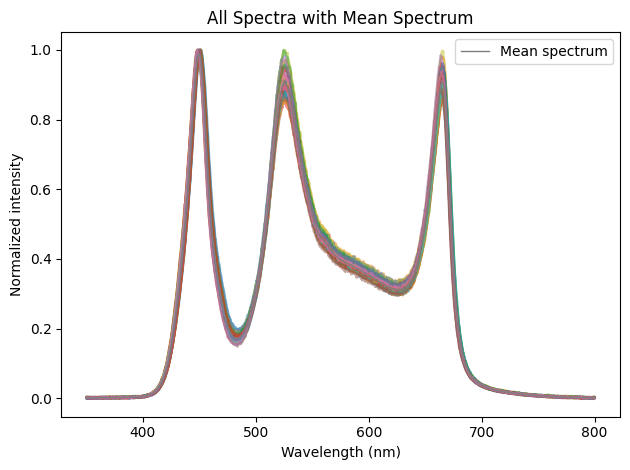

In [27]:
# Plot all spectra overlapped + mean spectrum
mean_spec = np.mean(spectra, axis=1) # axis = 1 means it is calculating the mean across columns
                                     # so getting a mean across all stressor stations for each wavelength
plt.figure()
for i in range(spectra.shape[1]):
    plt.plot(wl, spectra[:, i], alpha=0.5) # alpha is setting transparency for the spectra from each station
plt.plot(wl, mean_spec, linewidth=1, label='Mean spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized intensity')
plt.title('All Spectra with Mean Spectrum')
plt.legend()
plt.tight_layout()
plt.show()

### Create a Histogram at a Single Wavelength

Now that you have plotted all of the spectra, you will explore how the normalized intensity varies across stressing stations at a **single wavelength** of your choosing.

**To complete the cell below:**

1. **Choose a wavelength.** Look at the spectra plot above and pick a wavelength of interest (e.g., near a peak, in a valley, or on a shoulder). Set `TARGET_WAVELENGTH` to your chosen value in nm. If you leave it as `None`, it will default to the peak wavelength of the mean spectrum.

2. **Choose a binning method.** Uncomment **one** of the two `plt.hist(...)` lines (Option 1 or Option 2). Option 1 lets you set the number of bins manually; Option 2 lets matplotlib choose automatically. Try both and decide which one gives a clearer picture of the distribution.

3. **Run the cell** to see the histogram with a Gaussian fit overlaid.

**Try several different wavelengths** (e.g., near the peaks, in the valleys between peaks, on the shoulders). Does the shape of the distribution change depending on which wavelength you choose? Does the Gaussian fit describe some wavelengths better than others?

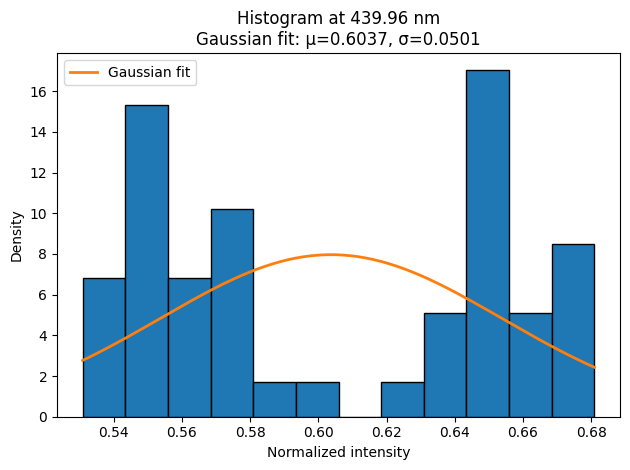

Used wavelength: 439.96 nm
Gaussian μ=0.603735, σ=0.050092


In [30]:
# Select a wavelength and edit the TARGET_WAVELENGTH variable to create histogram
TARGET_WAVELENGTH = 440  # UPDATE THIS to your chosen wavelength (e.g., 460)

# Histogram at chosen wavelength + Gaussian fit
if TARGET_WAVELENGTH is None:
    idx = int(np.nanargmax(mean_spec))
    target_nm = float(wl[idx]) # Safety check - did you update your wavelength variable above?
else:
    # It will find the closest wavelength value to what is placed in TARGET_WAVELENGTH variable
    idx = int(np.nanargmin(np.abs(wl - TARGET_WAVELENGTH)))
    target_nm = float(wl[idx])

vals = spectra[idx, :] # pulls all intensity values at that wavelength across stations
vals = vals[~np.isnan(vals)] # drop any NaN values
mu = float(np.mean(vals))
sigma = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0

# Decide which binning method to use and UNCOMMENT (remove the #) the line of code
# of the method you select. Perhaps try both methods and choose the one you think
# works best.
# 'density = True' in the plt.hist normalizes the bin heights such that the integral of the histogram is equal to 1.

#Option 1: You set the bin width
plt.hist(vals, bins=12, density=True, edgecolor='black') #you set bin width

# Option 2: Bin width is auto-set
# plt.hist(vals, density=True, edgecolor="black")

if sigma > 0: # this if statement is a safety check - kicks you out if there is zero spread
    xs = np.linspace(vals.min(), vals.max(), 200)
    pdf = 1.0 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)
    plt.plot(xs, pdf, linewidth=2.0, label='Gaussian fit')
    plt.legend()
plt.xlabel('Normalized intensity')
plt.ylabel('Density')
plt.title(f'Histogram at {target_nm:.2f} nm\nGaussian fit: μ={mu:.4f}, σ={sigma:.4f}')
plt.tight_layout()
plt.show()

# Print the fit parameters of your Gaussian
print(f"Used wavelength: {target_nm:.2f} nm\nGaussian μ={mu:.6f}, σ={sigma:.6f}")

#### **Question 2**: Look at your histograms at several different wavelengths. Describe the shape of the distributions you observe. Is a Gaussian a good model for the data at every wavelength? If not, what features do you see (e.g., multiple peaks, skewness, outliers), and what might cause them?

The shape of the distribution changes at different wavelengths. At 440nm, like the graph above, there is a bimodal distribution, which the gaussian is not a good model for. At the limits of intensity, near 1, the gaussian is scewed toward the left becuase fewer readings are at the maximum intensity. The Guassian isn't the best model for every wavelength, but works well for many of them.

#### **Question 3**: Compare the fitted values of μ and σ across the wavelengths you explored. How do the spread and center of the distribution change at different parts of the spectrum? What does this tell you about the consistency of the stressing station lights?

The standard deviation (σ) tells us how spread out the data is, and the gaussian (μ) shows the center of the distribution. If we look at the *All Spectra* graph, the places with large slopes have less centralized distributions and a larger standard deviation of intensities. We might assume that the stressing stations are less consistent in the areas where the wavelengths have a steep slope.


## **EQE Analysis**

1) Create a CSV file with your EQE values for this week. Remember you can copy and paste code from your Python tutorial. Consider using a loop in your python code to be more efficient.

2) Use all of your EQE data CSV files (Baseline through this week [Data Collection 5]) to generate subplots for each pixel showing how the EQE spectrum changes over time. Each subplot should include all **seven** time points (baseline, Data Collection 1, Data Collection 2, break week, Data Collection 3, Data Collection 4, and Data Collection 5), accounting for any pixels that may have failed during stressing.

In [8]:
# --- EQE Calculation with Standard Error Uncertainty ---

date_str = "2026_03_24"

# Physical constants
h = 6.62607015e-34       # Planck's constant (J*s)
c = 3.0e8                # Speed of light (m/s)
e_charge = 1.602176634e-19  # Elementary charge (C)

# Load power data (shared across all pixels for one apparatus)
power_fname = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/EQE_Data/2026_03_24_power_cellR22.csv"
power_data = pd.read_csv(power_fname)
print(f"[ok] Loaded power data: {power_fname}")

# try:
#     power_data = pd.read_csv(power_fname)
#     print(f"[ok] Loaded power data: {power_fname}")
# except FileNotFoundError:
#     print(f"[error] Power file not found: {power_fname}")
#     print("  Update the filename above to match your power data file.")

wavelength_nm = power_data["Wavelength (nm)"].to_numpy()
wavelength_m  = wavelength_nm * 1e-9

P_mean_uW = power_data["Power_mean (uW)"].to_numpy()
P_std_uW  = power_data["Power_std (uW)"].to_numpy()
n_P       = power_data["n"].to_numpy().astype(float)

# SE of power
SE_P_uW = np.where(n_P > 1, P_std_uW / np.sqrt(n_P), np.nan)

# Build EQE results dataframe
eqe_df = pd.DataFrame({"Wavelength (nm)": wavelength_nm})

folder_name = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/EQE_Data"


for pix in sorted(jv_data.keys()):
    curr_fname = f"{folder_name}/{date_str}_current_cell{cell_id}_pixel{pix}.csv"
    try:
        curr_data = pd.read_csv(curr_fname)

        I_mean_nA = curr_data["Current_mean (nA)"].to_numpy()
        I_std_nA  = curr_data["Current_std (nA)"].to_numpy()
        n_I       = curr_data["n"].to_numpy().astype(float)

        # SE of current
        SE_I_nA = np.where(n_I > 1, I_std_nA / np.sqrt(n_I), np.nan)

        # Convert to SI units
        I_mean_A = I_mean_nA * 1e-9
        SE_I_A   = SE_I_nA * 1e-9
        P_mean_W = P_mean_uW * 1e-6
        SE_P_W   = SE_P_uW * 1e-6

        # EQE calculation
        eqe_vals = (I_mean_A / P_mean_W) * (h * c) / (e_charge * wavelength_m)

        # EQE uncertainty propagation: dEQE/EQE = sqrt((dI/I)^2 + (dP/P)^2)
        rel_I = SE_I_A / np.abs(I_mean_A)
        rel_P = SE_P_W / np.abs(P_mean_W)
        eqe_unc = np.abs(eqe_vals) * np.sqrt(rel_I**2 + rel_P**2)

        eqe_df[f"eqe_pix{pix}"]     = eqe_vals
        eqe_df[f"eqe_unc_pix{pix}"] = eqe_unc

        print(f"[ok] Pixel {pix}: peak EQE = {np.nanmax(eqe_vals):.4f} "
              f"({np.nanmax(eqe_vals)*100:.1f}%)")
    except FileNotFoundError:
        print(f"[skip] Pixel {pix}: current file not found ({curr_fname})")
    except Exception as e:
        print(f"[skip] Pixel {pix}: {e}")

# Write to CSV
eqe_out = f"{date_str}_eqe_cell{cell_id}.csv"
eqe_df.to_csv(eqe_out, index=False)
print(f"\n[ok] Wrote {eqe_out}")

[ok] Loaded power data: /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/EQE_Data/2026_03_24_power_cellR22.csv
[ok] Pixel 1: peak EQE = 0.7514 (75.1%)
[ok] Pixel 2: peak EQE = 0.7827 (78.3%)
[ok] Pixel 3: peak EQE = 0.8417 (84.2%)
[ok] Pixel 4: peak EQE = 0.8856 (88.6%)
[ok] Pixel 5: peak EQE = 0.7555 (75.6%)
[ok] Pixel 6: peak EQE = 0.9215 (92.2%)
[ok] Pixel 7: peak EQE = 0.7656 (76.6%)
[ok] Pixel 8: peak EQE = 0.8444 (84.4%)

[ok] Wrote 2026_03_24_eqe_cellR22.csv


[ok] Loaded Week 2: /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week2/2026_02_03_eqe_cellR22.csv
[ok] Loaded Week 3: /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week3/2026_02_10_eqe_cellR22.csv
[ok] Loaded Week 4: /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week4/2026_02_17_eqe_cellR22.csv
[ok] Loaded Week 5: /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week5/2026_02_24_eqe_cellR22.csv
[ok] Loaded Week 6: /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week6/2026_03_03_eqe_cellR22.csv
[ok] Loaded Week 7: /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/2026_03_10_eqe_cellR22.csv
[ok] Loaded Week 8: /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/2026_03_24_eqe_cellR22.csv


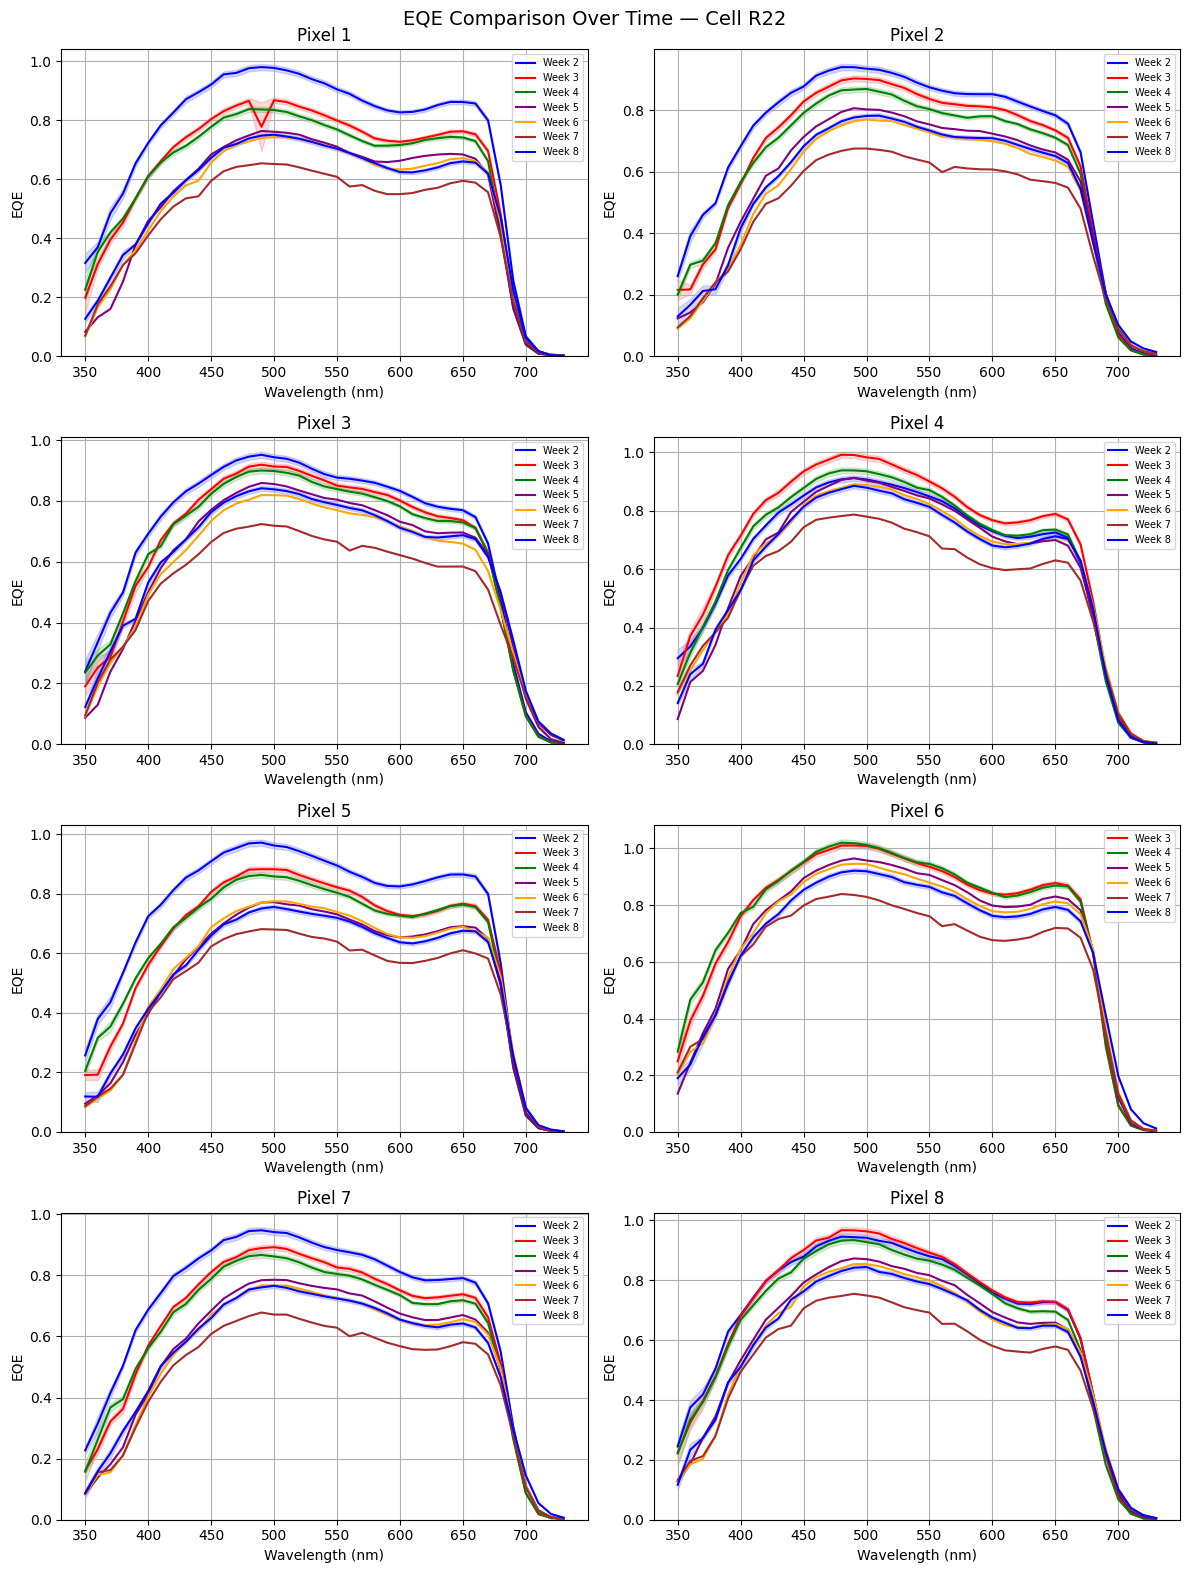

In [31]:
# --- Multi-Week EQE Comparison with Uncertainty Bands ---

# Add your EQE CSV files here (update filenames each week)
eqe_files = {
    "Week 2": "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week2/2026_02_03_eqe_cellR22.csv",
    "Week 3": "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week3/2026_02_10_eqe_cellR22.csv",
    "Week 4": "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week4/2026_02_17_eqe_cellR22.csv",
    "Week 5": "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week5/2026_02_24_eqe_cellR22.csv",
    "Week 6": "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week6/2026_03_03_eqe_cellR22.csv",
    "Week 7": "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/2026_03_10_eqe_cellR22.csv",
    "Week 8": "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week8/2026_03_24_eqe_cellR22.csv",
    # Add more weeks as needed
}

# Color cycle for different weeks
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']

# Load all EQE files
eqe_weeks = {}
for label, fname in eqe_files.items():
    try:
        eqe_weeks[label] = pd.read_csv(fname)
        print(f"[ok] Loaded {label}: {fname}")
    except FileNotFoundError:
        print(f"[skip] {label}: {fname} not found")

if not eqe_weeks:
    print("[warn] No EQE files loaded. Check filenames above.")
else:
    fig, axes = plt.subplots(4, 2, figsize=(12, 16))
    axes_flat = axes.flatten()

    for i in range(8):
        ax = axes_flat[i]
        pix = i + 1
        col_eqe = f"eqe_pix{pix}"
        col_unc = f"eqe_unc_pix{pix}"

        for j, (label, df_eqe) in enumerate(eqe_weeks.items()):
            color = colors[j % len(colors)]
            wl = df_eqe["Wavelength (nm)"].to_numpy()

            if col_eqe in df_eqe.columns:
                eqe_vals = df_eqe[col_eqe].to_numpy()
                ax.plot(wl, eqe_vals, color=color, label=label)

                # Add uncertainty band if the column exists
                if col_unc in df_eqe.columns:
                    eqe_unc = df_eqe[col_unc].to_numpy()
                    ax.fill_between(wl,
                                    eqe_vals - eqe_unc,
                                    eqe_vals + eqe_unc,
                                    alpha=0.15, color=color)

        ax.set_title(f"Pixel {pix}")
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("EQE")
        ax.legend(fontsize=7)
        ax.set_ylim(bottom=0)
        ax.grid(True)

    plt.suptitle(f"EQE Comparison Over Time — Cell {cell_id}", fontsize=14)
    plt.tight_layout()
    plt.show()


#### **Question 4:** Discuss what you observe from looking at the comparison of all  of your EQE curves.

Looking at our previous EQE curves we can see a pattern of constant decreasing for all our pixels. All of our pixels we're a lot lower in week seven for some reason. This could have to do with our equipment, and not necessarilly the cell's degradation rate. There has also been a consistent high reading for pixel 6. We don't have the data from week one because of how weird it was. As the week's have gone on, we see it slowly starting to decline.

# **Author Contributions (required)**
Greg - Data collection, code, histogram analysis.
Madelyn - Data collection, reflection questions, histogram analysis.
Jay - Reflection questions, histogram analysis.


# **Use of AI (required)**
ChatGPT was used at the end for debugging purposes.


